In [1]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "creditcard_2023.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "creditcard_2023.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

#### Primeiramente, carregar os dados e certificar-se que não há valores nulos

In [2]:
df = pd.read_csv(DATA_PATH)

In [3]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,568630.000000,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.118237e-17,-5.118237e-17,1.023647e-16,0.000000,2.559118e-17,2.559118e-17,0.000000,1.279559e-17,0.000000,...,1.279559e-17,1.599449e-18,5.598072e-18,-2.559118e-17,-4.478457e-17,-6.397796e-18,-2.559118e-17,3.198898e-17,12041.957635,0.5
std,164149.486122,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222,-9.952786e+00,-2.111111e+01,-4.351839,-1.075634e+01,-3.751919,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-0.656020,-2.934955e-01,-4.458712e-01,-0.283533,-1.922572e-01,-0.568745,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-0.073762,8.108788e-02,7.871758e-02,0.233366,-1.145242e-01,0.092526,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,0.707005,4.397368e-01,4.977881e-01,0.525955,4.729905e-02,0.559262,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536,4.271689e+01,2.616840e+01,217.873038,5.958040e+00,20.270062,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


### Features do nosso dataset possui seguintes descrições:
- id: Identificador único de cada transação
- V1-V28: Features anonimizadas representando vários atributos de transação (e.g., hora, local, etc.)
- Amount: Quantia da transação
- Class: Label binário indicando se a transação é fraudulenta (1) ou não (0)

---



In [4]:
df = df.dropna()

### Na sequência, precisamos remover a coluna de ID já que não queremos que o modelo tente encontrar padrões com relação a coluna

In [5]:
df_new = df.drop(columns=['id'])

In [6]:
df_new.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


### Agora precisamos separar as features do target
---

In [7]:
x = df_new.drop(columns=['Class'])
y = df_new['Class']

### Vamos fazer a primeira divisão de dados entre valores the teste para o dataset em 15% para teste final

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

### Nesse caso, vamos separar o restante dos 85% dos valores em 15% para validação, sendo assim necessário realizar o cálculo de 15% de 85%

In [10]:
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.176,
                                                  random_state=42)

In [11]:
print(y_val)

195244    0
320794    1
250048    0
168841    0
157558    0
         ..
208190    0
212393    0
406154    1
125252    0
203368    0
Name: Class, Length: 85067, dtype: int64


### Por fim, antes de treinar nosso modelo, vamos redimensionar a coluna 'Amount' para nosso modelo

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [13]:
x_train['Amount'] = scaler.fit_transform(x_train[['Amount']])
x_val['Amount'] = scaler.transform(x_val[['Amount']])
x_test['Amount'] = scaler.transform(x_test[['Amount']])

In [14]:
print(x_train)

              V1        V2        V3        V4        V5        V6        V7  \
1073    0.564962 -0.950762  0.938249 -0.409262 -0.228403  0.307938  0.341585   
421536 -0.582531  0.031150 -0.502832  0.027323 -0.080069 -0.281998 -0.157652   
145870  0.046660 -0.523766  0.506981 -1.277160 -0.006884  0.644934  1.001560   
9920    0.687131 -0.601300  1.255898  0.129578  0.011934  0.870281  0.312489   
104030  0.907508 -0.382694  0.983246 -0.194705  0.048841  0.161627  0.401312   
...          ...       ...       ...       ...       ...       ...       ...   
352407 -1.313066  0.383372 -0.961087  1.372283 -1.019468  0.250598 -1.297973   
112119 -0.269945 -0.046288  0.911788 -0.266263  0.198894 -0.056337  0.628223   
53625   1.021194 -0.373817  0.557490 -0.403801  0.158602  0.127050  0.399354   
6030    0.066971 -0.022556  0.536564  0.144090  0.967716  0.144664  1.591439   
385601 -0.710400 -0.696839 -0.321473 -0.009675 -0.248900  0.326212 -0.256528   

              V8        V9       V10  .

## Seguir agora com a validação do modelo de Regressão Logística

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [17]:
y_val_pred = log_reg.predict(x_val)
y_val_proba = log_reg.predict_proba(x_val)[:, 1]

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.9648865012284434
Precision: 0.9766584766584766
Recall: 0.9525879284824847
F1-score: 0.964473042568122
ROC-AUC: 0.993333885365416
PR-AUC: 0.9945329586828879

Confusion Matrix:
[[41535   969]
 [ 2018 40545]]

Classification Report:


              precision    recall  f1-score   support

           0       0.95      0.98      0.97     42504
           1       0.98      0.95      0.96     42563

    accuracy                           0.96     85067
   macro avg       0.97      0.96      0.96     85067
weighted avg       0.97      0.96      0.96     85067



### Criar tabela de comparação para futura análise de resultados com modelo não supervisionado

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred)
    ],
    "Precision": [
        precision_score(y_val, y_val_pred)
    ],
    "Recall": [
        recall_score(y_val, y_val_pred)
    ],
    "F1-score": [
        f1_score(y_val, y_val_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_val, y_val_proba)
    ]
})

results.to_csv(RESULTS_DIR / "logistic_regression_metrics.csv", index=False)
results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.964887,0.976658,0.952588,0.964473,0.993334,0.994533


mkdir -p failed for path C:\Users\gentig\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\gentig\\.matplotlib'


Matplotlib created a temporary cache directory at C:\Users\gentig\AppData\Local\Temp\matplotlib-je4k6usw because there was an issue with the default path (C:\Users\gentig\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\gentig\\AppData\\Local\\Temp\\matplotlib-je4k6usw\\fontlist-v390.json.matplotlib-lock'


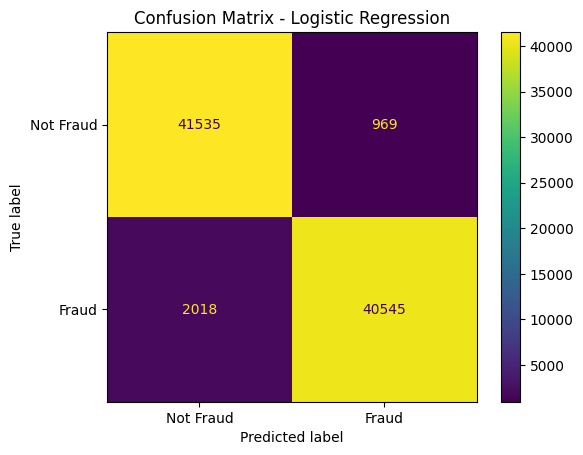

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig(RESULTS_DIR / "confusion_matrix_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()